In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option("display.max_columns", None)

# Load Dataset

In [2]:
master_df = pd.read_parquet(
    "../../data/processed/wbpcb_master.parquet"
)

master_df["datetime"] = pd.to_datetime(
    master_df["datetime"]
)

print(master_df.shape)

master_df.head()

(508116, 15)


,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,wind_direction,wind_speed_avg,wind_speed_min,wind_speed_max
0,2022-01-01 21:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,123,66.79,109.32,71.50,18.09,0,0.0,0.0,0.0
1,2022-01-01 21:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,193,87.98,173.04,72.72,18.48,0,0.0,0.0,0.0
2,2022-01-01 21:00:00,WB015,Sarsuna College,Kolkata,22.481270,88.284554,185,85.59,194.13,73.95,18.51,0,0.0,0.0,0.0
3,2022-01-01 22:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,145,73.56,156.15,75.74,17.73,0,0.0,0.0,0.0
4,2022-01-01 22:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,231,99.37,168.51,75.08,18.05,0,0.0,0.0,0.0


# Dataset Overview

In [3]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Rows      :", len(master_df))
print("Columns   :", len(master_df.columns))
print("Stations  :", master_df["station_id"].nunique())

print("\nDate Range")
print(master_df["datetime"].min())
print(master_df["datetime"].max())

DATASET OVERVIEW
Rows      : 508116
Columns   : 15
Stations  : 17

Date Range
2022-01-01 21:00:00
2026-05-30 21:00:00


# Missing Values

In [4]:
missing = pd.DataFrame({
    "Missing Count": master_df.isnull().sum(),
    "Missing %": (
        master_df.isnull().mean()*100
    ).round(2)
})

missing.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
datetime,0,0.0
station_id,0,0.0
station_name,0,0.0
district,0,0.0
latitude,0,0.0
longitude,0,0.0
aqi,0,0.0
pm25,0,0.0
pm10,0,0.0
humidity,0,0.0


# Duplicate Records

In [5]:
duplicates = master_df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 62


# Station Coverage Report

In [6]:
coverage = (
    master_df
    .groupby(
        ["station_id","station_name"]
    )
    .agg(
        records=("datetime","count"),
        start=("datetime","min"),
        end=("datetime","max")
    )
    .reset_index()
)

coverage.sort_values(
    "records",
    ascending=False
)

,station_id,station_name,records,start,end
16,WB017,"VIVEKANANDA COLLEGE FOR WOMEN, BARISHA",37803,2022-01-10 11:00:00,2026-05-30 21:00:00
14,WB015,Sarsuna College,37313,2022-01-01 21:00:00,2026-05-30 21:00:00
4,WB005,"East Calcutta Girls College, Lake Town",36539,2022-01-01 21:00:00,2026-05-30 21:00:00
0,WB001,Avidipta Housing Complex,36115,2022-03-14 21:00:00,2026-05-30 14:00:00
13,WB014,Sarojini Naidu College for Women,35472,2022-03-02 13:00:00,2026-05-30 21:00:00
15,WB016,Urbana Housing Complex,35403,2022-04-05 13:00:00,2026-05-30 21:00:00
8,WB009,Leather Complex,35071,2022-01-01 21:00:00,2026-05-30 21:00:00
5,WB006,Flora Fountain,34751,2022-04-19 15:00:00,2026-05-30 21:00:00
12,WB013,Presidency University,32568,2022-07-14 20:00:00,2026-05-30 21:00:00
10,WB011,Madhyamgram Municipality,31586,2022-08-10 14:00:00,2026-05-30 21:00:00


# Basic Statistics

In [7]:
master_df[
    [
        "aqi",
        "pm25",
        "pm10",
        "humidity",
        "temperature",
        "wind_speed_avg"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
aqi,508116.0,91.014473,63.770344,1.00,48.00,73.00,110.00,697.000000
pm25,508116.0,46.295677,27.999283,-149.94,25.99,40.44,60.75,473.250000
pm10,508116.0,83.094077,53.867389,-56.83,45.59,68.86,106.18,667.920000
humidity,508116.0,73.056144,15.844533,0.00,62.75,75.83,85.76,99.000000
temperature,508116.0,28.381904,5.866441,-17.60,25.40,28.72,31.32,157.360000
wind_speed_avg,508116.0,0.004434,0.090390,0.00,0.00,0.00,0.00,32.646667


# AQI Distribution

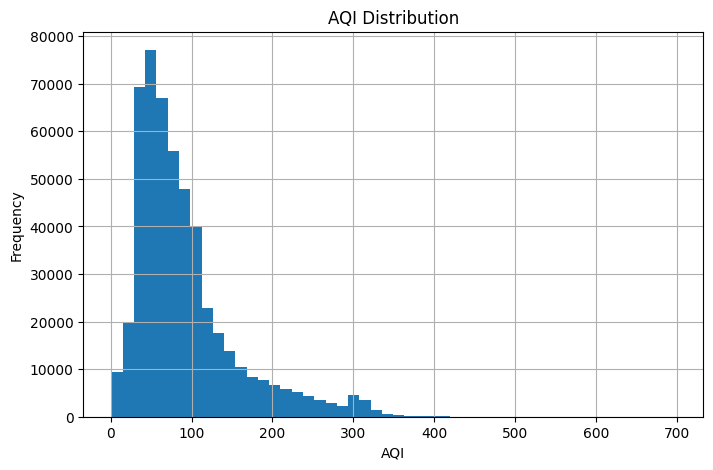

In [8]:
plt.figure(figsize=(8,5))

master_df["aqi"].hist(
    bins=50
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

# PM2.5 Distribution

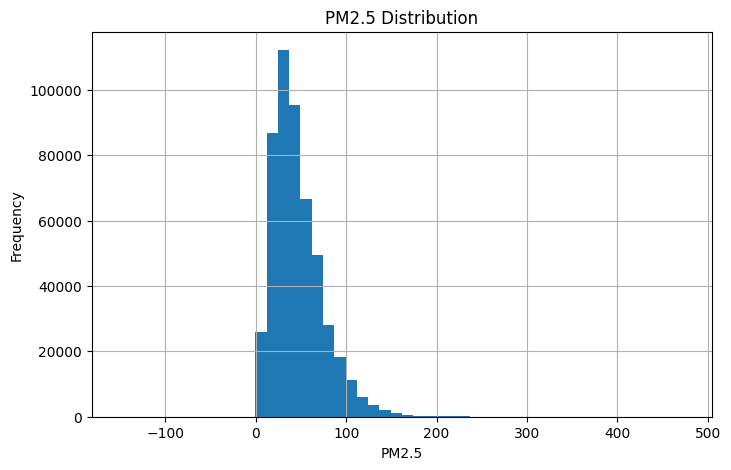

In [9]:
plt.figure(figsize=(8,5))

master_df["pm25"].hist(
    bins=50
)

plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

# Station-wise AQI

In [11]:
station_stats = (
    master_df
    .groupby("station_name")
    ["aqi"]
    .agg(
        [
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
    .round(2)
)

station_stats.to_csv(
    "../../src/reports/station_aqi_stats.csv"
)

# Top Polluted Stations

In [12]:
top_stations = (
    master_df
    .groupby("station_name")
    ["aqi"]
    .mean()
    .sort_values(ascending=False)
)

top_stations.head(10)

station_name
Ballygunge Campus, C.U                      111.570031
Madhyamgram Municipality                    101.966821
Dhapa Lock Pumping Station                   99.925539
Presidency University                        97.206491
Lorreto College                              97.152840
Flora Fountain                               96.497770
Lady Brabourne College                       96.408662
Bethune College                              93.368039
Sarojini Naidu College for Women             92.937726
East Calcutta Girls College, Lake Town       92.671420
Name: aqi, dtype: float64

#  AQI by Station Plot

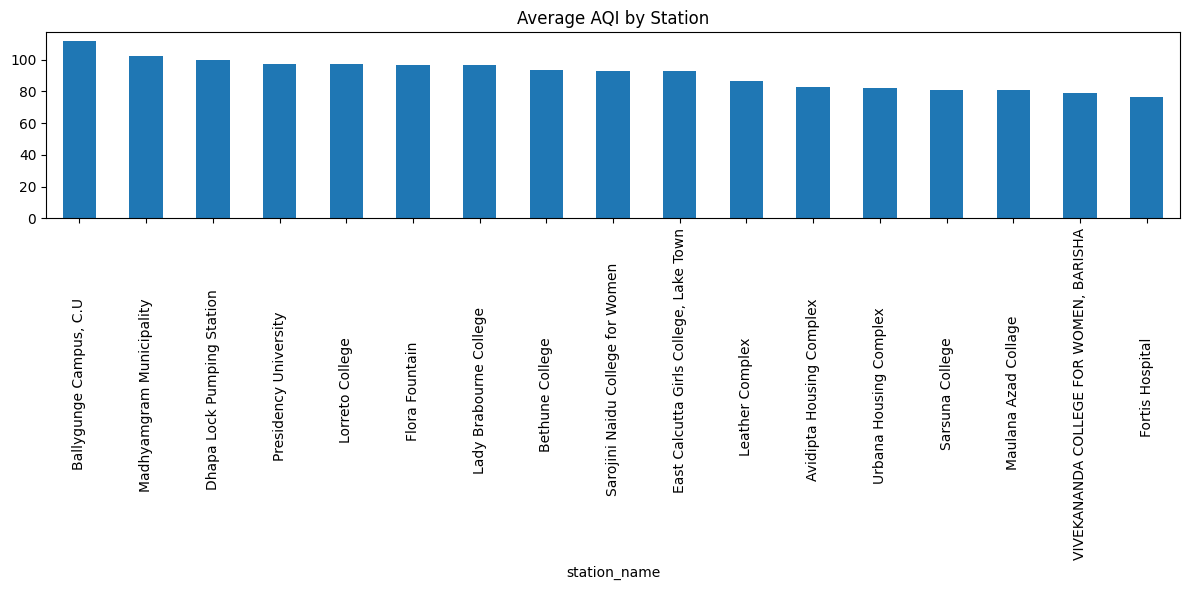

In [13]:
plt.figure(figsize=(12,6))

top_stations.plot(
    kind="bar"
)

plt.title("Average AQI by Station")

plt.tight_layout()

plt.show()

# Monthly Data Availability

In [14]:
monthly = (
    master_df
    .groupby(
        master_df["datetime"]
        .dt.to_period("M")
    )
    .size()
)

monthly.head()

datetime
2022-01    2614
2022-02    2504
2022-03    3717
2022-04    4766
2022-05    5352
Freq: M, dtype: int64

# Monthly Coverage Plot

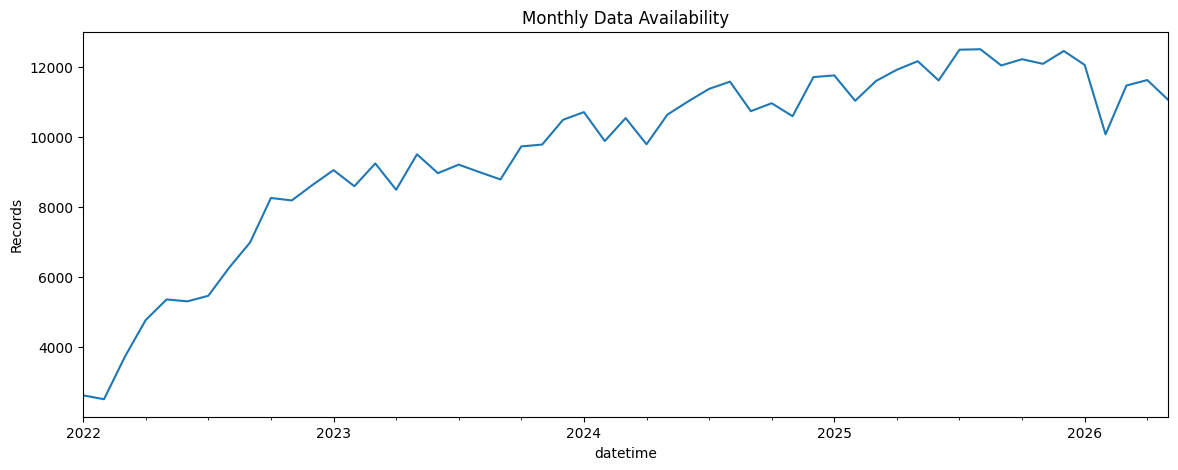

In [15]:
monthly.plot(
    figsize=(14,5)
)

plt.title(
    "Monthly Data Availability"
)

plt.ylabel("Records")

plt.show()

# Correlation Matrix

In [16]:
corr_cols = [
    "aqi",
    "pm25",
    "pm10",
    "humidity",
    "temperature",
    "wind_speed_avg"
]

corr = master_df[
    corr_cols
].corr()

corr

,aqi,pm25,pm10,humidity,temperature,wind_speed_avg
aqi,1.000000,0.973672,0.944812,-0.187178,-0.374694,0.027729
pm25,0.973672,1.000000,0.922765,-0.194086,-0.369864,0.026993
pm10,0.944812,0.922765,1.000000,-0.224238,-0.351312,0.024179
humidity,-0.187178,-0.194086,-0.224238,1.000000,-0.169708,-0.011022
temperature,-0.374694,-0.369864,-0.351312,-0.169708,1.000000,-0.009785
wind_speed_avg,0.027729,0.026993,0.024179,-0.011022,-0.009785,1.000000


# Correlation Heatmap

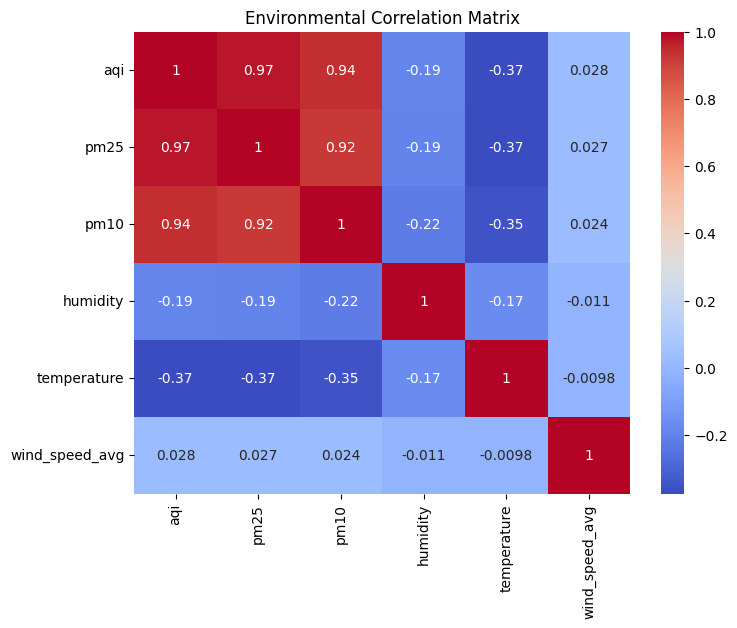

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Environmental Correlation Matrix"
)

plt.show()

# Outlier Analysis (IQR)

In [18]:
def count_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (
        (series < lower) |
        (series > upper)
    ).sum()

for col in ["aqi","pm25","pm10"]:

    print(
        col,
        count_outliers(master_df[col])
    )

aqi 37251
pm25 13516
pm10 22152


# Save Quality Report

In [19]:
summary = {
    "records":
        len(master_df),

    "stations":
        master_df["station_id"]
        .nunique(),

    "start_date":
        str(master_df["datetime"].min()),

    "end_date":
        str(master_df["datetime"].max()),

    "duplicates":
        int(master_df.duplicated().sum())
}

pd.DataFrame(
    [summary]
).to_csv(
    "../../src/reports/data_quality_summary.csv",
    index=False
)

summary

{'records': 508116,
 'stations': 17,
 'start_date': '2022-01-01 21:00:00',
 'end_date': '2026-05-30 21:00:00',
 'duplicates': 62}

In [21]:
cols = [
    'aqi',
    'pm25',
    'pm10',
    'humidity',
    'temperature',
    'wind_direction',
    'wind_speed_avg',
    'wind_speed_min',
    'wind_speed_max'
]

for col in cols:
    print(f"\n{col}")
    print("-"*40)
    print("Unique Values:", master_df[col].nunique())
    print("Zero %:",
          round((master_df[col] == 0).mean() * 100, 2))


aqi
----------------------------------------
Unique Values: 493
Zero %: 0.0

pm25
----------------------------------------
Unique Values: 16593
Zero %: 0.0

pm10
----------------------------------------
Unique Values: 29834
Zero %: 0.0

humidity
----------------------------------------
Unique Values: 7878
Zero %: 0.14

temperature
----------------------------------------
Unique Values: 4140
Zero %: 0.14

wind_direction
----------------------------------------
Unique Values: 1
Zero %: 100.0

wind_speed_avg
----------------------------------------
Unique Values: 10552
Zero %: 97.15

wind_speed_min
----------------------------------------
Unique Values: 2219
Zero %: 97.76

wind_speed_max
----------------------------------------
Unique Values: 2818
Zero %: 97.15


In [22]:
master_df.groupby("station_name")[
    "wind_speed_avg"
].agg(
    [
        ("records", "count"),
        ("non_zero",
         lambda x: (x > 0).sum())
    ]
)

,records,non_zero
station_name,,
Avidipta Housing Complex,36115,18
"Ballygunge Campus, C.U",27602,17
Bethune College,15838,278
Dhapa Lock Pumping Station,27182,10791
"East Calcutta Girls College, Lake Town",36539,57
Flora Fountain,34751,10
Fortis Hospital,13277,345
Lady Brabourne College,30732,11
Leather Complex,35071,29
